In [77]:
import os 

os.listdir('/kaggle/input/iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset')

['IQ-OTH_NCCD lung cancer dataset.txt',
 'Normal cases',
 'Bengin cases',
 'Malignant cases']

**Cấu hình đường dẫn**

In [78]:
import torch

save_dir = "/kaggle/working/"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = '/kaggle/input/iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset'
batch = 32
ep = 400
img_size = (224,224)
pth = '/kaggle/working/mobilenet_v3_large.pth'

**Augmentation, DataLoader**

In [79]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader, Dataset
import random
from PIL import Image

DATASET_PATH = data 
BATCH_SIZE = batch
SEED = 42

random.seed(SEED)
torch.manual_seed(SEED)

class GrayImageFolder(datasets.ImageFolder):
    def __getitem__(self, index):
        path, target = self.samples[index]
        sample = Image.open(path).convert('L') 
        if self.transform is not None:
            sample = self.transform(sample)
        return sample, target

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=2),
    # transforms.RandomAffine(
    #     degrees=0,
    #     translate=(0.01, 0.01),
    #     scale=(0.9, 1.1),
    #     shear=5
    # ),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.3)),
    transforms.ToTensor(),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

full_dataset = datasets.ImageFolder(root=DATASET_PATH)
total_size = len(full_dataset)
test_size = int(0.1 * total_size)
train_val_size = total_size - test_size
indices = list(range(total_size))
random.shuffle(indices)
test_indices = indices[:test_size]
train_val_indices = indices[test_size:]
val_size = int(0.2 * len(train_val_indices))  
train_size = len(train_val_indices) - val_size
train_indices = train_val_indices[:train_size]
val_indices = train_val_indices[train_size:]

class TransformedDataset(Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __getitem__(self, idx):
        image, label = self.dataset[self.indices[idx]]  
        image = self.transform(image)
        return image, label 

    def __len__(self):
        return len(self.indices)

train_dataset = TransformedDataset(full_dataset, train_indices, train_transform)
val_dataset = TransformedDataset(full_dataset, val_indices, val_test_transform)
test_dataset = TransformedDataset(full_dataset, test_indices, val_test_transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Total images: {total_size}')
print(f'Train: {len(train_dataset)}')
print(f'Val:   {len(val_dataset)}')
print(f'Test:  {len(test_dataset)}')

assert len(set(train_indices) & set(val_indices)) == 0, "Train và Val bị trùng!"
assert len(set(train_indices) & set(test_indices)) == 0, "Train và Test bị trùng!"
assert len(set(val_indices) & set(test_indices)) == 0, "Val và Test bị trùng!"
print("No overlap between train, val, and test sets.")

Total images: 1097
Train: 791
Val:   197
Test:  109
No overlap between train, val, and test sets.


In [80]:
print(type(train_loader.dataset))


<class '__main__.TransformedDataset'>


In [81]:
# def mean_std(loader):
#     mean = 0.
#     std = 0.
#     total_images_count = 0
    
#     for images, _ in loader:
#         batch_samples = images.size(0) 
#         images = images.view(batch_samples, images.size(1), -1)  
#         mean += images.mean(dim=2).sum(dim=0)  
#         std += images.std(dim=2).sum(dim=0) 
#         total_images_count += batch_samples
    
#     mean /= total_images_count
#     std /= total_images_count
    
#     return mean, std

# mean, std = mean_std(train_loader)
# print(mean, std)

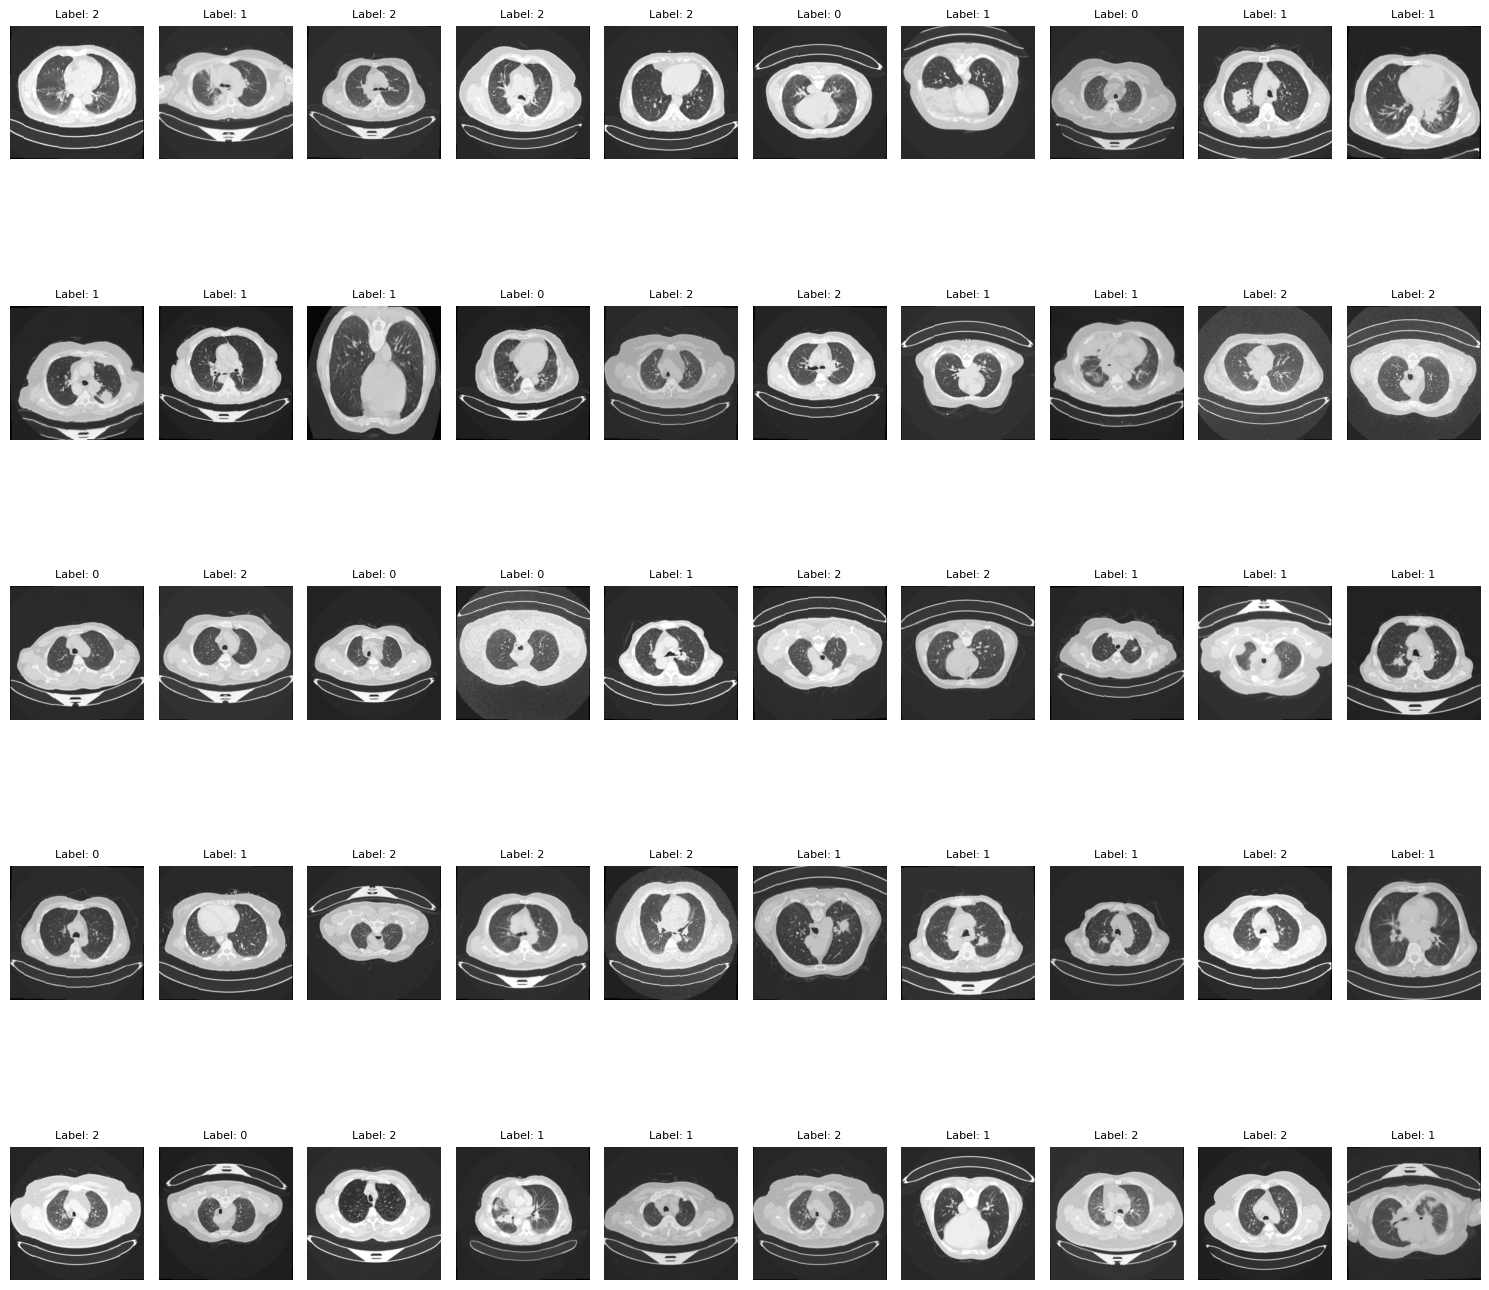

In [82]:
import matplotlib.pyplot as plt
import numpy as np

def show_images_from_loader(data_loader, num_images=50):
    images_shown = 0
    plt.figure(figsize=(15, 15))
    
    for images, labels in data_loader:
        for i in range(images.size(0)):
            if images_shown >= num_images:
                break
            
            img = images[i].permute(1, 2, 0).numpy()
            
            plt.subplot(5, 10, images_shown + 1)
            plt.imshow(img)
            plt.title(f"Label: {labels[i].item()}", fontsize=8)
            plt.axis('off')
            images_shown += 1
        
        if images_shown >= num_images:
            break

    plt.tight_layout()
    plt.show()

show_images_from_loader(train_loader)

**Mô hình**

**MobileNet V1**

In [83]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, stride):
        super(DepthwiseSeparableConv, self).__init__()
        self.depthwise = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=stride, padding=1, groups=in_channels, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True)
        )
        self.pointwise = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x

class MobileNetV1(nn.Module):
    def __init__(self, num_classes=3):
        super(MobileNetV1, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            DepthwiseSeparableConv(32, 64, stride=1),
            DepthwiseSeparableConv(64, 128, stride=2),
            DepthwiseSeparableConv(128, 128, stride=1),
            DepthwiseSeparableConv(128, 256, stride=2),
            DepthwiseSeparableConv(256, 256, stride=1),
            DepthwiseSeparableConv(256, 512, stride=2),

            DepthwiseSeparableConv(512, 512, stride=1),
            DepthwiseSeparableConv(512, 512, stride=1),
            DepthwiseSeparableConv(512, 512, stride=1),
            DepthwiseSeparableConv(512, 512, stride=1),
            DepthwiseSeparableConv(512, 512, stride=1),

            DepthwiseSeparableConv(512, 1024, stride=2),
            DepthwiseSeparableConv(1024, 1024, stride=1),

            nn.AdaptiveAvgPool2d(1),
        )
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.model(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

**MobileNet V2**

In [84]:
class InvertedResidual(nn.Module):
    def __init__(self, in_channels, out_channels, stride, expand_ratio):
        super(InvertedResidual, self).__init__()
        hidden_dim = int(in_channels * expand_ratio)
        self.use_residual = stride == 1 and in_channels == out_channels

        layers = []
        if expand_ratio != 1:
            layers.append(nn.Conv2d(in_channels, hidden_dim, 1, 1, 0, bias=False))
            layers.append(nn.BatchNorm2d(hidden_dim))
            layers.append(nn.ReLU6(inplace=True))
        
        layers.extend([
            nn.Conv2d(hidden_dim, hidden_dim, 3, stride, 1, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU6(inplace=True),

            nn.Conv2d(hidden_dim, out_channels, 1, 1, 0, bias=False),
            nn.BatchNorm2d(out_channels)
        ])

        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_residual:
            return x + self.conv(x)
        else:
            return self.conv(x)

class MobileNetV2(nn.Module):
    def __init__(self, num_classes=3, width_mult=1.0):
        super(MobileNetV2, self).__init__()
        input_channel = int(32 * width_mult)
        last_channel = int(1280 * width_mult) if width_mult > 1.0 else 1280

        inverted_residual_setting = [
            # t, c, n, s
            [3, 16, 1, 1],
            [6, 24, 2, 2],
            [6, 32, 3, 2],
            [6, 64, 4, 2],
            [6, 96, 3, 1],
            [6, 160, 3, 2],
            [6, 320, 1, 1],
        ]

        features = [nn.Conv2d(3, input_channel, 3, stride=2, padding=1, bias=False),
                    nn.BatchNorm2d(input_channel),
                    nn.ReLU6(inplace=True)]

        for t, c, n, s in inverted_residual_setting:
            output_channel = int(c * width_mult)
            for i in range(n):
                stride = s if i == 0 else 1
                features.append(InvertedResidual(input_channel, output_channel, stride, expand_ratio=t))
                input_channel = output_channel

        features.append(nn.Conv2d(input_channel, last_channel, 1, 1, 0, bias=False))
        features.append(nn.BatchNorm2d(last_channel))
        features.append(nn.ReLU6(inplace=True))

        self.drop = nn.Dropout(0.6)
        self.features = nn.Sequential(*features)
        self.classifier = nn.Linear(last_channel, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = nn.functional.adaptive_avg_pool2d(x, (1, 1))
        x = torch.flatten(x, 1)
        x = self.drop(x)
        x = self.classifier(x)
        return x

**MobileNet V3 Small**

In [85]:
class HardSwish(nn.Module):
    def forward(self, x):
        return x * F.relu6(x + 3) / 6

class SqueezeExcite(nn.Module):
    def __init__(self, in_channels, reduction=4):
        super().__init__()
        reduced_channels = max(1, in_channels // reduction)
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Conv2d(in_channels, reduced_channels, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(reduced_channels, in_channels, 1),
            nn.Hardsigmoid(inplace=True)
        )

    def forward(self, x):
        scale = self.squeeze(x)
        scale = self.excitation(scale)
        return x * scale

class MobileBottleneck(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, expand_ratio, use_se, activation):
        super().__init__()
        hidden_dim = int(in_channels * expand_ratio)
        self.use_res_connect = stride == 1 and in_channels == out_channels

        layers = []
        if expand_ratio != 1:
            layers.append(nn.Conv2d(in_channels, hidden_dim, 1, bias=False))
            layers.append(nn.BatchNorm2d(hidden_dim))
            layers.append(nn.ReLU(inplace=True) if activation == "RE" else HardSwish())
        layers.extend([
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size, stride, kernel_size // 2, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU(inplace=True) if activation == "RE" else HardSwish()
        ])
        if use_se:
            layers.append(SqueezeExcite(hidden_dim))
        layers.extend([
            nn.Conv2d(hidden_dim, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels)
        ])

        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_res_connect:
            return x + self.conv(x)
        else:
            return self.conv(x)

class MobileNetV3Small(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, 3, 2, 1, bias=False),
            nn.BatchNorm2d(16),
            HardSwish()
        )
        self.blocks = nn.Sequential(
            MobileBottleneck(16, 16, 3, 2, 1, True, "RE"),
            MobileBottleneck(16, 24, 3, 2, 72//16, False, "RE"),
            MobileBottleneck(24, 24, 3, 1, 88//24, False, "RE"),
            MobileBottleneck(24, 40, 5, 2, 4, True, "HS"),
            MobileBottleneck(40, 40, 5, 1, 6, True, "HS"),
            MobileBottleneck(40, 40, 5, 1, 6, True, "HS"),
            MobileBottleneck(40, 48, 5, 1, 3, True, "HS"),
            MobileBottleneck(48, 48, 5, 1, 3, True, "HS"),
            MobileBottleneck(48, 96, 5, 2, 6, True, "HS"),
            MobileBottleneck(96, 96, 5, 1, 6, True, "HS"),
            MobileBottleneck(96, 96, 5, 1, 6, True, "HS"),
        )
        self.final = nn.Sequential(
            nn.Conv2d(96, 576, 1, bias=False),
            nn.BatchNorm2d(576),
            HardSwish(),
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(576, 1280, 1),
            HardSwish()
        )
        self.drop = nn.Dropout(0.3)
        self.classifier = nn.Linear(1280, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        x = self.final(x)
        x = x.view(x.size(0), -1)
        x = self.drop(x)
        x = self.classifier(x)
        return x

**MbileNetV3 Large**

In [86]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class HardSwish(nn.Module):
    def forward(self, x):
        return x * F.relu6(x + 3) / 6

class SqueezeExcite(nn.Module):
    def __init__(self, in_channels, reduction=4):
        super().__init__()
        reduced_channels = max(1, in_channels // reduction)
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Conv2d(in_channels, reduced_channels, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(reduced_channels, in_channels, 1),
            nn.Hardsigmoid(inplace=True)
        )

    def forward(self, x):
        scale = self.squeeze(x)
        scale = self.excitation(scale)
        return x * scale

class MobileBottleneck(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, expand_ratio, use_se, activation):
        super().__init__()
        hidden_dim = int(in_channels * expand_ratio)
        self.use_res_connect = stride == 1 and in_channels == out_channels

        layers = []
        if expand_ratio != 1:
            layers += [
                nn.Conv2d(in_channels, hidden_dim, 1, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.ReLU(inplace=True) if activation == "RE" else HardSwish()
            ]
        layers += [
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size, stride, kernel_size // 2, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU(inplace=True) if activation == "RE" else HardSwish()
        ]
        if use_se:
            layers.append(SqueezeExcite(hidden_dim))
        layers += [
            nn.Conv2d(hidden_dim, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels)
        ]
        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_res_connect:
            return x + self.conv(x)
        else:
            return self.conv(x)

class MobileNetV3Large(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(16),
            HardSwish()
        )

        self.blocks = nn.Sequential(
            MobileBottleneck(16, 16, 3, 1, 1, False, "RE"),
            MobileBottleneck(16, 24, 3, 2, 4, False, "RE"),
            MobileBottleneck(24, 24, 3, 1, 3, False, "RE"),
            MobileBottleneck(24, 40, 5, 2, 3, True, "RE"),
            MobileBottleneck(40, 40, 5, 1, 3, True, "RE"),
            MobileBottleneck(40, 40, 5, 1, 3, True, "RE"),
            MobileBottleneck(40, 80, 3, 2, 6, False, "HS"),
            MobileBottleneck(80, 80, 3, 1, 2.5, False, "HS"),
            MobileBottleneck(80, 80, 3, 1, 2.3, False, "HS"),
            MobileBottleneck(80, 80, 3, 1, 2.3, False, "HS"),
            MobileBottleneck(80, 112, 3, 1, 6, True, "HS"),
            MobileBottleneck(112, 112, 3, 1, 6, True, "HS"),
            MobileBottleneck(112, 160, 5, 2, 6, True, "HS"),
            MobileBottleneck(160, 160, 5, 1, 6, True, "HS"),
            MobileBottleneck(160, 160, 5, 1, 6, True, "HS"),
        )

        self.final = nn.Sequential(
            nn.Conv2d(160, 960, 1, bias=False),
            nn.BatchNorm2d(960),
            HardSwish(),
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(960, 1280, 1),
            HardSwish()
        )

        self.drop = nn.Dropout(0.3)
        self.classifier = nn.Linear(1280, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        x = self.final(x)
        x = x.view(x.size(0), -1)
        x = self.drop(x)
        x = self.classifier(x)
        return x

**EfficientNet B0**

In [87]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

class SEBlock(nn.Module):
    def __init__(self, input_channels, se_ratio=0.25):
        super().__init__()
        squeezed_channels = max(1, int(input_channels * se_ratio))
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Conv2d(input_channels, squeezed_channels, 1),
            Swish(),
            nn.Conv2d(squeezed_channels, input_channels, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        scale = self.excitation(self.squeeze(x))
        return x * scale

class MBConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, expand_ratio, kernel_size, stride, se_ratio=0.25):
        super().__init__()
        mid_channels = in_channels * expand_ratio
        self.use_residual = (stride == 1 and in_channels == out_channels)
        
        layers = []
        if expand_ratio != 1:
            layers.append(nn.Conv2d(in_channels, mid_channels, 1, bias=False))
            layers.append(nn.BatchNorm2d(mid_channels))
            layers.append(Swish())
        
        layers.extend([
            nn.Conv2d(mid_channels, mid_channels, kernel_size, stride, kernel_size // 2, groups=mid_channels, bias=False),
            nn.BatchNorm2d(mid_channels),
            Swish()
        ])

        self.se = SEBlock(mid_channels, se_ratio)
        
        layers.extend([
            nn.Conv2d(mid_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels)
        ])
        
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        out = self.block(x)
        out = self.se(out)
        return x + out if self.use_residual else out

class EfficientNetB0(nn.Module):
    def __init__(self, num_classes=1000):
        super().__init__()
        base_channels = 32
        self.stem = nn.Sequential(
            nn.Conv2d(3, base_channels, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(base_channels),
            Swish()
        )
        
        self.blocks = nn.Sequential(
            # stage 1
            MBConvBlock(32, 16, expand_ratio=1, kernel_size=3, stride=1),
            # stage 2
            MBConvBlock(16, 24, expand_ratio=6, kernel_size=3, stride=2),
            MBConvBlock(24, 24, expand_ratio=6, kernel_size=3, stride=1),
            # stage 3
            MBConvBlock(24, 40, expand_ratio=6, kernel_size=5, stride=2),
            MBConvBlock(40, 40, expand_ratio=6, kernel_size=5, stride=1),
            # stage 4
            MBConvBlock(40, 80, expand_ratio=6, kernel_size=3, stride=2),
            MBConvBlock(80, 80, expand_ratio=6, kernel_size=3, stride=1),
            MBConvBlock(80, 80, expand_ratio=6, kernel_size=3, stride=1),
            # stage 5
            MBConvBlock(80, 112, expand_ratio=6, kernel_size=5, stride=1),
            MBConvBlock(112, 112, expand_ratio=6, kernel_size=5, stride=1),
            # stage 6
            MBConvBlock(112, 192, expand_ratio=6, kernel_size=5, stride=2),
            MBConvBlock(192, 192, expand_ratio=6, kernel_size=5, stride=1),
            MBConvBlock(192, 192, expand_ratio=6, kernel_size=5, stride=1),
            MBConvBlock(192, 192, expand_ratio=6, kernel_size=5, stride=1),
            # stage 7
            MBConvBlock(192, 320, expand_ratio=6, kernel_size=3, stride=1),
        )

        self.head = nn.Sequential(
            nn.Conv2d(320, 1280, 1, bias=False),
            nn.BatchNorm2d(1280),
            Swish(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(1280, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        x = self.head(x)
        return x

**EfficientNet B1**

In [88]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

class SqueezeExcite(nn.Module):
    def __init__(self, in_channels, se_ratio=0.25):
        super().__init__()
        squeezed_channels = max(1, int(in_channels * se_ratio))
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, squeezed_channels, kernel_size=1),
            Swish(),
            nn.Conv2d(squeezed_channels, in_channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.se(x)
        return x * scale

class MBConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, expand_ratio, kernel_size, stride):
        super().__init__()
        self.stride = stride
        self.use_residual = (in_channels == out_channels and stride == 1)
        hidden_dim = in_channels * expand_ratio

        layers = []
        if expand_ratio != 1:
            layers.extend([
                nn.Conv2d(in_channels, hidden_dim, kernel_size=1, bias=False),
                nn.BatchNorm2d(hidden_dim),
                Swish(),
            ])

        layers.extend([
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=kernel_size, stride=stride,
                      padding=kernel_size // 2, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim),
            Swish(),
            SqueezeExcite(hidden_dim),
            nn.Conv2d(hidden_dim, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
        ])

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_residual:
            return x + self.block(x)
        else:
            return self.block(x)

class EfficientNetB1(nn.Module):
    def __init__(self, num_classes=1000):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            Swish(),
        )

        self.blocks = nn.Sequential(
            MBConvBlock(32, 16, expand_ratio=1, kernel_size=3, stride=1),

            MBConvBlock(16, 24, expand_ratio=6, kernel_size=3, stride=2),
            MBConvBlock(24, 24, expand_ratio=6, kernel_size=3, stride=1),

            MBConvBlock(24, 40, expand_ratio=6, kernel_size=5, stride=2),
            MBConvBlock(40, 40, expand_ratio=6, kernel_size=5, stride=1),
            MBConvBlock(40, 40, expand_ratio=6, kernel_size=5, stride=1),

            MBConvBlock(40, 80, expand_ratio=6, kernel_size=3, stride=2),
            MBConvBlock(80, 80, expand_ratio=6, kernel_size=3, stride=1),
            MBConvBlock(80, 80, expand_ratio=6, kernel_size=3, stride=1),
            MBConvBlock(80, 80, expand_ratio=6, kernel_size=3, stride=1),

            MBConvBlock(80, 112, expand_ratio=6, kernel_size=5, stride=1),
            MBConvBlock(112, 112, expand_ratio=6, kernel_size=5, stride=1),
            MBConvBlock(112, 112, expand_ratio=6, kernel_size=5, stride=1),
            MBConvBlock(112, 112, expand_ratio=6, kernel_size=5, stride=1),

            MBConvBlock(112, 192, expand_ratio=6, kernel_size=5, stride=2),
            MBConvBlock(192, 192, expand_ratio=6, kernel_size=5, stride=1),
            MBConvBlock(192, 192, expand_ratio=6, kernel_size=5, stride=1),
            MBConvBlock(192, 192, expand_ratio=6, kernel_size=5, stride=1),
            MBConvBlock(192, 192, expand_ratio=6, kernel_size=5, stride=1),

            MBConvBlock(192, 320, expand_ratio=6, kernel_size=3, stride=1),
            MBConvBlock(320, 320, expand_ratio=6, kernel_size=3, stride=1),
        )

        self.head = nn.Sequential(
            nn.Conv2d(320, 1280, kernel_size=1, bias=False),
            nn.BatchNorm2d(1280),
            Swish(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(1280, num_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        x = self.head(x)
        return x

**Huấn luyện mô hình**

In [89]:
class EarlyStopping:
    def __init__(self, patience=3, delta=0, path=pth):
        self.patience = patience
        self.delta = delta
        self.path = path
        self.best_loss = float('inf') 
        self.counter = 0  
        self.early_stop = False  

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.path)  
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

In [90]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        if self.alpha is not None:
            alpha_t = self.alpha.gather(0, targets)
            focal_loss *= alpha_t
        return focal_loss.mean()

In [91]:
import torch.nn as nn
import torch

class LabelSmoothingLoss(nn.Module):
    def __init__(self, classes, smoothing=0.1):
        super(LabelSmoothingLoss, self).__init__()
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.cls = classes
        self.criterion = nn.KLDivLoss(reduction='batchmean')

    def forward(self, pred, target):
        pred = pred.log_softmax(dim=-1)
        true_dist = torch.zeros_like(pred)
        true_dist.fill_(self.smoothing / (self.cls - 1))
        true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
        return self.criterion(pred, true_dist)

In [92]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report

model = MobileNetV3Large(num_classes=3).to(device)

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Số lượng tham số đang học: {count_trainable_params(model):,}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=400)
early_stopping = EarlyStopping(patience=20, delta=0.01, path=pth)

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    train_acc_l, train_loss_l, val_acc_l, val_loss_l = [], [], [], []

    total_start_time = time.time()
    
    for epochs in range(num_epochs):
        epoch_start_time = time.time()
        model.train()
        t_loss = 0.
        t_correct, t_total = 0, 0

        loop = tqdm(train_loader, desc=f"Epoch {epochs+1}/{num_epochs}")
        for images, labels in loop:
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()

            _, train_predict = torch.max(outputs.data, 1)
            t_correct += (train_predict == labels).sum().item()
            t_total += labels.size(0)

        train_loss = t_loss/len(train_loader)
        train_acc = t_correct/t_total * 100
        train_loss_l.append(train_loss)
        train_acc_l.append(train_acc)

        model.eval()
        v_loss = 0.
        v_correct, v_total = 0, 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                v_loss += loss.item()

                _, v_predict = torch.max(outputs.data, 1)
                v_correct += (v_predict == labels).sum().item()
                v_total += labels.size(0)

        val_loss = v_loss/len(val_loader)
        val_acc = v_correct/v_total * 100
        val_loss_l.append(val_loss)
        val_acc_l.append(val_acc)
        epoch_time = time.time() - epoch_start_time

        print(f'{epochs+1}/{num_epochs}: t_acc: {train_acc: .2f}, t_loss: {train_loss: .2f}, v_acc: {val_acc: .2f}, v_loss: {val_loss: .2f}, time: {epoch_time:.2f}s')
        
        scheduler.step(val_loss)
        
        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            break

    total_time = time.time() - total_start_time
    print(f"Tổng thời gian huấn luyện: {total_time/60:.2f} phút")

    y_pred_class, y_true_class = [], []
    model.eval()
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predict = torch.max(outputs.data, 1)
            y_pred_class.extend(predict.cpu().numpy())
            y_true_class.extend(labels.cpu().numpy())

    model.load_state_dict(torch.load(pth))
    return train_acc_l, train_loss_l, val_acc_l, val_loss_l, y_pred_class, y_true_class

train_acc_l, train_loss_l, val_acc_l, val_loss_l, y_pred_class, y_true_class = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=400)
torch.save(model.state_dict(), pth)

Số lượng tham số đang học: 4,204,041


Epoch 1/400: 100%|██████████| 25/25 [00:10<00:00,  2.37it/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


1/400: t_acc:  55.75, t_loss:  0.95, v_acc:  49.24, v_loss:  0.96, time: 11.86s


Epoch 2/400: 100%|██████████| 25/25 [00:10<00:00,  2.30it/s]


2/400: t_acc:  58.66, t_loss:  0.88, v_acc:  49.24, v_loss:  1.06, time: 12.18s


...

Epoch 65/400: 100%|██████████| 25/25 [00:10<00:00,  2.31it/s]


65/400: t_acc:  98.86, t_loss:  0.04, v_acc:  95.94, v_loss:  0.09, time: 12.11s


Epoch 66/400: 100%|██████████| 25/25 [00:10<00:00,  2.34it/s]


66/400: t_acc:  98.99, t_loss:  0.03, v_acc:  97.46, v_loss:  0.05, time: 12.04s
Tổng thời gian huấn luyện: 13.27 phút


/tmp/ipykernel_31/3234728983.py:96: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(pth))


              precision    recall  f1-score   support

           0       0.90      0.95      0.93        20
           1       1.00      0.98      0.99        99
           2       0.96      0.97      0.97        78

    accuracy                           0.97       197
   macro avg       0.96      0.97      0.96       197
weighted avg       0.98      0.97      0.97       197



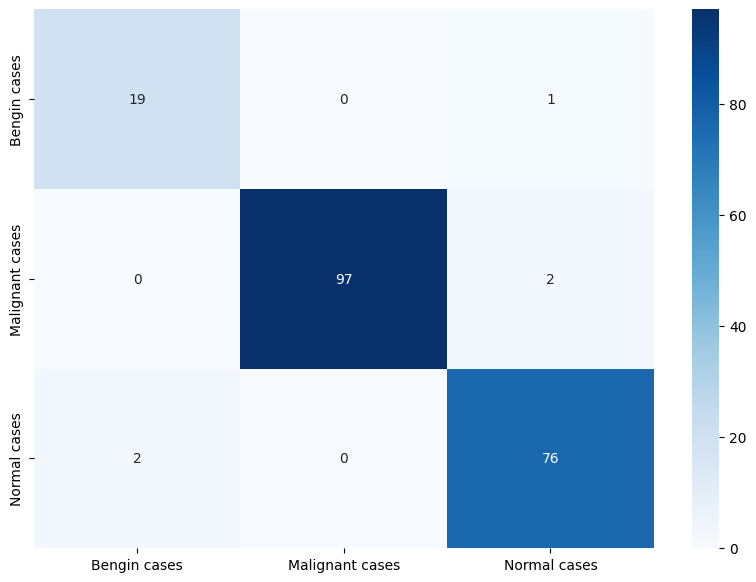

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os 

class_labels = classification_report(y_pred_class, y_true_class)
print(class_labels)

cm = confusion_matrix(y_pred_class, y_true_class)

plt.figure(figsize=(10,7))
sns.heatmap(cm, fmt='d', cmap='Blues', annot=True, xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)
plt.show()

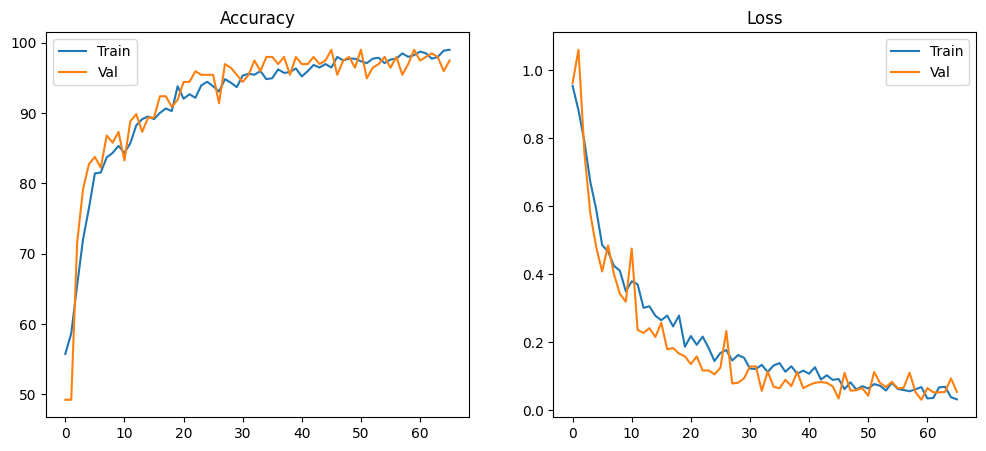

In [94]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].plot(train_acc_l)
ax[0].plot(val_acc_l)
ax[0].legend(['Train', 'Val'])
ax[0].set_title("Accuracy")

ax[1].plot(train_loss_l)
ax[1].plot(val_loss_l)
ax[1].legend(['Train', 'Val'])
ax[1].set_title("Loss")

plt.show()

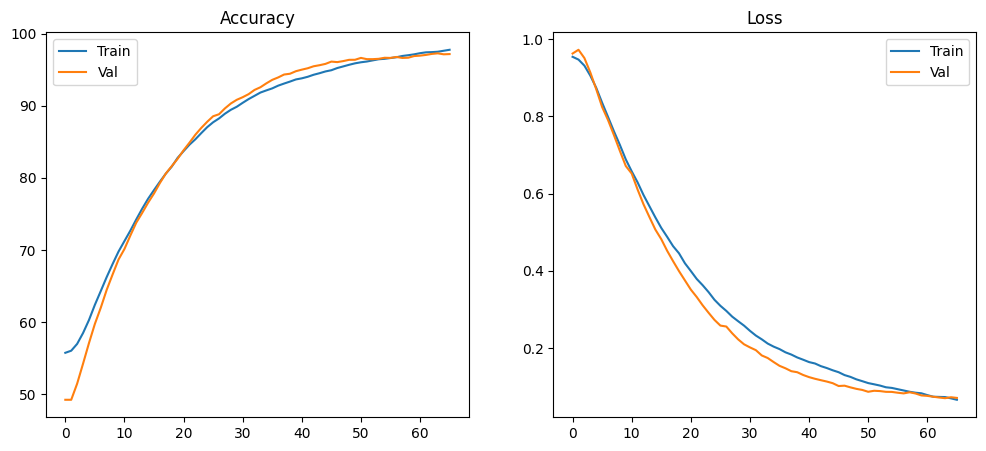

In [95]:
import matplotlib.pyplot as plt
import numpy as np

def smooth_curve(points, factor=0.9):
    smoothed = []
    last = points[0]
    for point in points:
        smoothed_val = last * factor + (1 - factor) * point
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed

train_acc_smoothed = smooth_curve(train_acc_l)
val_acc_smoothed = smooth_curve(val_acc_l)
train_loss_smoothed = smooth_curve(train_loss_l)
val_loss_smoothed = smooth_curve(val_loss_l)

fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].plot(train_acc_smoothed)
ax[0].plot(val_acc_smoothed)
ax[0].legend(['Train', 'Val'])
ax[0].set_title("Accuracy")

ax[1].plot(train_loss_smoothed)
ax[1].plot(val_loss_smoothed)
ax[1].legend(['Train', 'Val'])
ax[1].set_title("Loss")

plt.show()

Test Loss: 0.0687
Test Accuracy: 99.08%


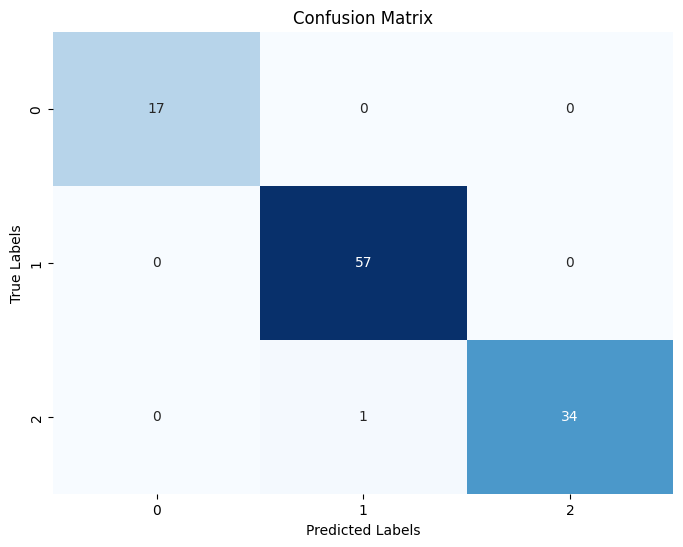

In [96]:
### import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def evaluate_on_test(model, test_loader, criterion, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model.eval()
    model.to(device)

    test_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * images.size(0)  

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy()) 
            all_labels.extend(labels.cpu().numpy())    

    avg_loss = test_loss / total
    accuracy = 100.0 * correct / total

    print(f'Test Loss: {avg_loss:.4f}')
    print(f'Test Accuracy: {accuracy:.2f}%')

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=True, yticklabels=True)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()

    return avg_loss, accuracy

# Sử dụng hàm evaluate_on_test
criterion = nn.CrossEntropyLoss()
test_loss, test_accuracy = evaluate_on_test(model, test_loader, criterion)

In [97]:
import torch
from torchvision import datasets
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, accuracy_score

lung_test_dataset = datasets.ImageFolder(
    root='/kaggle/input/lungcancertest/test_augmented',
    transform=val_test_transform
)

lung_test_loader = DataLoader(lung_test_dataset, batch_size=batch, shuffle=False)
class_names = lung_test_dataset.classes
print("Class names:", class_names)

model = MobileNetV3Large(num_classes=3).to(device)
model.load_state_dict(torch.load(pth, map_location=device))
model.eval()

predictions = []
true_labels = []

with torch.no_grad():
    for images, labels in lung_test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

print("Accuracy:", accuracy_score(true_labels, predictions))
print("\nClassification Report:")
print(classification_report(true_labels, predictions, target_names=class_names))

Class names: ['BenginCases', 'MalignantCases', 'normal']


/tmp/ipykernel_31/4197687356.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(pth, map_location=device))


Accuracy: 0.8509316770186336

Classification Report:
                precision    recall  f1-score   support

   BenginCases       0.40      0.91      0.56        11
MalignantCases       0.93      0.95      0.94        80
        normal       0.94      0.73      0.82        70

      accuracy                           0.85       161
     macro avg       0.76      0.86      0.77       161
  weighted avg       0.90      0.85      0.86       161



In [98]:
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

lung_test_dataset = datasets.ImageFolder(
    root='/kaggle/input/lungcancertest/test_augmented',
    transform=val_test_transform
)
lung_test_loader = DataLoader(lung_test_dataset, batch_size=batch, shuffle=False)
class_names = lung_test_dataset.classes
print("Class names:", class_names)

model = MobileNetV3Large().to(device)
model.load_state_dict(torch.load(pth, map_location=device))
model.eval()

def extract_features(loader):
    features = []
    labels = []
    
    with torch.no_grad():
        for images, label in loader:
            images = images.to(device)
            
            # feature = model.features(images)
            # feature = feature.view(feature.size(0), -1)

            x = model.stem(images)
            x = model.blocks(x)
            x = model.final(x)
            x = x.view(x.size(0), -1)

            features.append(x.cpu().numpy())
            labels.extend(label.numpy())
            
            # features.append(feature.cpu().numpy())
            # labels.extend(label)
    
    return np.concatenate(features), np.array(labels)

test_features, test_labels = extract_features(lung_test_loader)

lung_train_dataset =  datasets.ImageFolder(
    root=data,
    transform=val_test_transform
)
lung_train_loader = DataLoader(lung_train_dataset, batch_size=batch, shuffle=False)

train_features, train_labels = extract_features(lung_train_loader)

test_features = normalize(test_features)
train_features = normalize(train_features)

similarities = cosine_similarity(test_features, train_features)

threshold = 0.95
duplicates = 0
total_comparisons = len(test_features)

for i, similarity in enumerate(similarities):
    if np.max(similarity) > threshold:
        duplicates += 1

duplicate_percentage = (duplicates / total_comparisons) * 100

print(f"Duplicate percentage: {duplicate_percentage:.2f}%")

Class names: ['BenginCases', 'MalignantCases', 'normal']


/tmp/ipykernel_31/3085102842.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(pth, map_location=device))


Duplicate percentage: 91.93%
